<a href="https://colab.research.google.com/github/malakagunasekara/imageprocessing/blob/main/Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files


In [2]:
uploaded = files.upload()
image_name = list(uploaded.keys())[0]

# Load image and convert to grayscale
img = Image.open(image_name).convert("L")
img = np.array(img)


Saving runaway.png to runaway.png


In [3]:
def histogram_equalization(image):
    """
    Perform histogram equalization from scratch
    image: grayscale image (uint8)
    """
    # Flatten image
    pixels = image.flatten()

    # Compute histogram (256 gray levels)
    hist = np.zeros(256)
    for p in pixels:
        hist[p] += 1

    # Normalize histogram
    hist_norm = hist / pixels.size

    # Compute cumulative distribution function (CDF)
    cdf = np.cumsum(hist_norm)

    # Create transformation function
    transform = np.floor(255 * cdf).astype(np.uint8)

    # Apply transformation
    equalized_img = transform[image]

    return equalized_img, hist, transform


In [4]:
eq_img, hist_original, transform = histogram_equalization(img)


In [5]:
hist_eq = np.zeros(256)
for p in eq_img.flatten():
    hist_eq[p] += 1


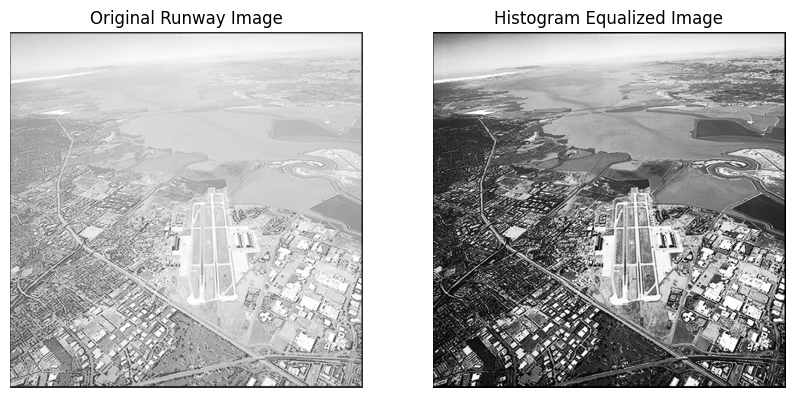

In [6]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Runway Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(eq_img, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis('off')

plt.show()


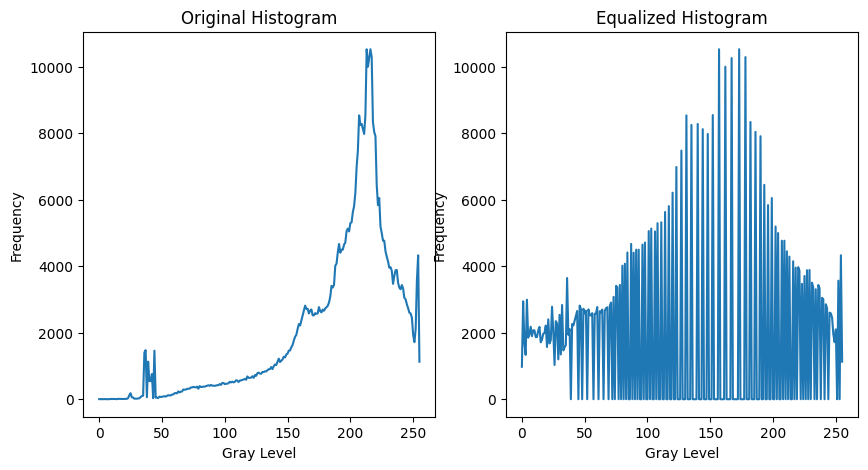

In [7]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(hist_original)
plt.title("Original Histogram")
plt.xlabel("Gray Level")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.plot(hist_eq)
plt.title("Equalized Histogram")
plt.xlabel("Gray Level")
plt.ylabel("Frequency")

plt.show()
